# Step 4: Exploratory data analysis

Input: `data/processed/quakes_clean.csv` (set `USE_SAMPLE = True` to work on
`quakes_sample.csv`, 2024-2025 only, while writing code).
Output: figures `figures/step4_*.png`, numbers `results/eda_summary.csv`,
`results/known_events.csv` and `results/step4_*.csv`.

Every number quoted in the slides comes from the `results/` files written here.

In [1]:
import sys
sys.path.append("../scripts")
from config import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

USE_SAMPLE = False

# same look as Step 3
BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
# depth classes are ordered: one blue, light -> dark (ordinal ramp, steps 250 / 450 / 650)
DEPTH_COLORS = {"shallow": "#86b6ef", "intermediate": "#2a78d6", "deep": "#104281"}
DEPTH_ORDER = ["shallow", "intermediate", "deep"]
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True, "grid.color": GRID,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "font.size": 10,
})
thousands = FuncFormatter(lambda v, _: f"{v:,.0f}")

for folder in (FIGURES_DIR, RESULTS_DIR):
    folder.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name):
    fig.savefig(FIGURES_DIR / name, dpi=FIG_DPI, bbox_inches="tight")
    print("saved", FIGURES_DIR / name)

summary = []  # every headline number of this step -> results/eda_summary.csv
def fact(item, value):
    summary.append({"item": item, "value": value})
    print(f"{item}: {value}")

## 1. Load the clean data

In [2]:
df = pd.read_csv(SAMPLE_FILE if USE_SAMPLE else CLEAN_FILE, dtype={"id": str})
df["time"] = pd.to_datetime(df["time"], utc=True, format="ISO8601")
n = len(df)
last = df["time"].max()

fact("rows", n)
fact("first event (UTC)", str(df["time"].min()))
fact("last event (UTC)", str(last))
fact("grid cells with events", df["cell_id"].nunique())
df.head(3)

rows: 187547
first event (UTC): 2000-01-01 01:19:26.990000+00:00
last event (UTC): 2026-10-10 10:35:11.922000+00:00
grid cells with events: 1206


,id,time,year,month,latitude,longitude,depth,depth_class,depth_fixed,mag,...,region,cell_id,nst,gap,rms,dmin,horizontalError,depthError,magError,magNst
0,usp0009kjw,2000-01-01 01:19:26.990000+00:00,2000,1,41.927,20.543,10.0,shallow,True,4.5,...,Kosovo,40_20,NaN,NaN,1.14,NaN,NaN,NaN,NaN,18.0
1,usp0009kk5,2000-01-01 04:30:10.370000+00:00,2000,1,-26.012,-68.803,105.0,intermediate,False,4.5,...,Chile,-30_-70,NaN,NaN,0.91,NaN,NaN,NaN,NaN,15.0
2,usp0009kk8,2000-01-01 05:24:35.290000+00:00,2000,1,36.874,69.947,54.3,shallow,False,5.1,...,Afghanistan,35_65,NaN,NaN,0.83,NaN,NaN,12.7,NaN,NaN


## 2. Known earthquakes (sanity check for the data and for Steps 5-6)

For each event the plan names, take the largest earthquake in a time window and
a lat/lon box around it. Search by time and place, **not** by `region`: the
largest named events have their event name as `place` (for example the 2023
Turkey earthquakes are in region "Kahramanmaras earthquake sequence").

`followers_30d_300km` counts the M4.5+ earthquakes in the 30 days after the
event and within 300 km of it (aftershocks). Step 5 can check that its
clusters find these sequences.

In [3]:
EARTH_KM = 6371.0088

def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 2 * EARTH_KM * np.arcsin(np.sqrt(a))

# name, label, start, end, lat range, lon range
SEARCH = [
    ("Sumatra-Andaman", "Sumatra 2004", "2004-12-20", "2005-01-01", (-5, 15), (85, 105)),
    ("Tohoku, Japan", "Tohoku 2011", "2011-03-01", "2011-04-01", (33, 43), (138, 148)),
    ("Kahramanmaras, Turkey", "Turkey 2023", "2023-02-01", "2023-03-01", (35, 40), (34, 41)),
    ("Myanmar", "Myanmar 2025", "2025-03-20", "2025-04-10", (15, 25), (93, 100)),
    ("Kamchatka, Russia", "Kamchatka 2025", "2025-07-20", "2025-08-10", (48, 58), (155, 168)),
]
rows = []
for name, label, t0, t1, (la0, la1), (lo0, lo1) in SEARCH:
    box = df[(df["time"] >= pd.Timestamp(t0, tz="UTC")) & (df["time"] < pd.Timestamp(t1, tz="UTC"))
             & df["latitude"].between(la0, la1) & df["longitude"].between(lo0, lo1)]
    if box.empty:
        print("not in this data:", name)
        continue
    ev = box.loc[box["mag"].idxmax()]
    after = df[(df["time"] > ev["time"]) & (df["time"] <= ev["time"] + pd.Timedelta(days=30))]
    near = haversine_km(ev["latitude"], ev["longitude"], after["latitude"], after["longitude"]) <= 300
    rows.append({"event": name, "label": label, "id": ev["id"], "time": ev["time"],
                 "latitude": ev["latitude"], "longitude": ev["longitude"], "depth": ev["depth"],
                 "mag": ev["mag"], "magType": ev["magType"], "region": ev["region"],
                 "followers_30d_300km": int(near.sum())})
known = pd.DataFrame(rows)
known.to_csv(RESULTS_DIR / "known_events.csv", index=False)
known.drop(columns="label")

,event,id,time,latitude,longitude,depth,mag,magType,region,followers_30d_300km
0,Sumatra-Andaman,official20041226005853450_30,2004-12-26 00:58:53.450000+00:00,3.2950,95.9820,30.0,9.1,mw,2004 Sumatra - Andaman Islands Earthquake,278
1,"Tohoku, Japan",official20110311054624120_30,2011-03-11 05:46:24.120000+00:00,38.2970,142.3730,29.0,9.1,mww,Japan,1910
2,"Kahramanmaras, Turkey",us6000jllz,2023-02-06 01:17:34.342000+00:00,37.2256,37.0143,10.0,7.8,mww,Kahramanmaras earthquake sequence,169
3,Myanmar,us7000pn9s,2025-03-28 06:20:52.715000+00:00,22.0110,95.9363,10.0,7.7,mww,Burma (Myanmar),22
4,"Kamchatka, Russia",us6000qw60,2025-07-29 23:24:52.483000+00:00,52.4948,160.2395,35.0,8.8,mww,Russia,834


## 3. World map: earthquakes trace the plate boundaries

Colour = depth class, size = magnitude. Deep earthquakes sit behind the
trenches where one plate sinks under another.

saved C:\Users\user\Documents\assignment\earthquake_project\figures\step4_world_map.png


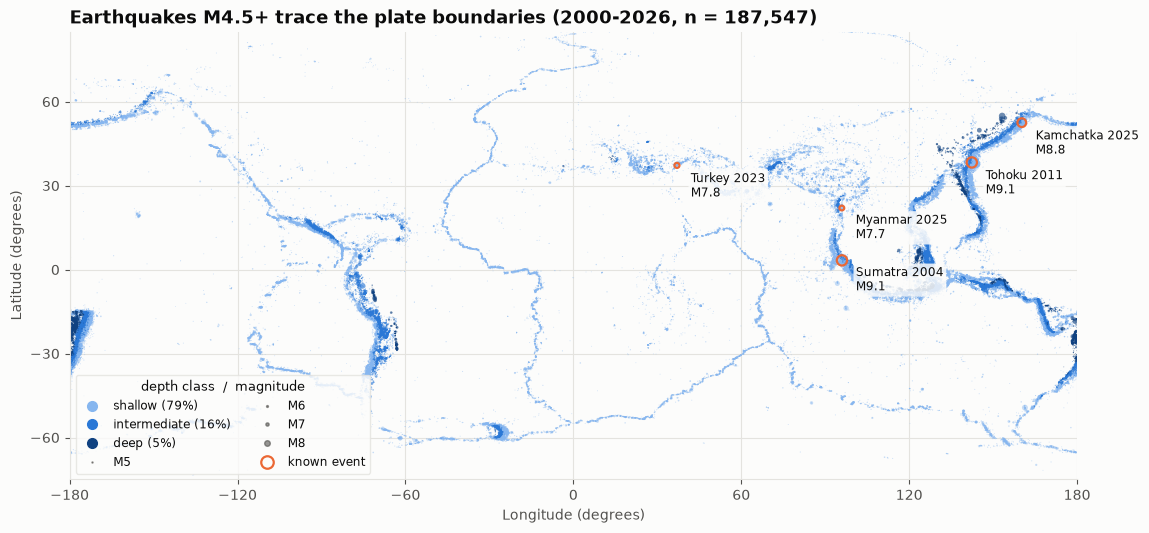

In [4]:
fig, ax = plt.subplots(figsize=(13, 6.6))
size = lambda m: 0.35 * 3.0 ** (m - MIN_MAG)          # each +1 magnitude = 3x the marker area
for cls in DEPTH_ORDER:                                  # deep on top: they are fewer
    s = df[df["depth_class"] == cls].sort_values("mag")
    ax.scatter(s["longitude"], s["latitude"], s=size(s["mag"]), c=DEPTH_COLORS[cls],
               alpha=0.45 if cls == "shallow" else 0.6, linewidths=0, rasterized=True)
for _, k in known.iterrows():
    ax.scatter(k["longitude"], k["latitude"], s=size(k["mag"]), facecolors="none",
               edgecolors=ORANGE, linewidths=1.6)
    ax.annotate(f"{k['label']}\nM{k['mag']:.1f}", (k["longitude"], k["latitude"]),
                xytext=(10, -4), textcoords="offset points", fontsize=8.5, color=INK, va="top",
                bbox={"boxstyle": "round,pad=0.2", "fc": SURFACE, "ec": "none", "alpha": 0.85})
ax.set_xlim(-180, 180); ax.set_ylim(-75, 85); ax.set_aspect("equal")
ax.set_xticks(range(-180, 181, 60)); ax.set_yticks(range(-60, 81, 30))
ax.set_xlabel("Longitude (degrees)"); ax.set_ylabel("Latitude (degrees)")
ax.set_title(f"Earthquakes M{MIN_MAG}+ trace the plate boundaries "
             f"({df['time'].dt.year.min()}-{df['time'].dt.year.max()}, n = {n:,})")

dist = df["depth_class"].value_counts()
handles = [Line2D([], [], ls="", marker="o", ms=7, color=DEPTH_COLORS[c],
                  label=f"{c} ({dist.get(c, 0) / n * 100:.0f}%)") for c in DEPTH_ORDER]
handles += [Line2D([], [], ls="", marker="o", ms=np.sqrt(size(m)), color=MUTED, alpha=0.6, label=f"M{m:g}")
            for m in (5, 6, 7, 8)]
handles += [Line2D([], [], ls="", marker="o", ms=9, mfc="none", mec=ORANGE, mew=1.6, label="known event")]
ax.legend(handles=handles, loc="lower left", ncol=2, frameon=True, facecolor=SURFACE,
          edgecolor=GRID, title="depth class  /  magnitude", title_fontsize=9, fontsize=8.5)
save_fig(fig, "step4_world_map.png")
plt.show()

## 4. Earthquakes over time

The last year is incomplete (data stops at the last download), so it is drawn
lighter and left out of the yearly average. Monthly peaks are labelled with the
largest earthquake of that month.

In [5]:
import re

def short(region):
    # "2004 Sumatra - Andaman Islands Earthquake" -> "Sumatra - Andaman Islands"
    region = re.sub(r"^\d{4}\s+", "", str(region))
    return re.sub(r"\s+earthquake(?: sequence)?$", "", region, flags=re.I)

per_year = df.groupby(df["time"].dt.year).size().rename("n").to_frame()
per_year.index.name = "year"
partial_year = last.year if last < pd.Timestamp(f"{last.year}-12-31", tz="UTC") else None
per_year["complete_year"] = per_year.index != partial_year
per_year.to_csv(RESULTS_DIR / "step4_events_per_year.csv")
full = per_year.loc[per_year["complete_year"], "n"]

month = df["time"].dt.tz_localize(None).dt.to_period("M")
per_month = df.groupby(month).agg(n=("id", "size"), max_mag=("mag", "max"))
idx_max = df.groupby(month)["mag"].idxmax()
per_month["largest_event"] = [f"{short(df.at[i, 'region'])} M{df.at[i, 'mag']:.1f}" for i in idx_max.values]
# a peak is explained by where its events are, not by the largest event elsewhere on Earth
by_region = df.groupby([month, "region"]).size().rename("k").reset_index()
top_reg = by_region.loc[by_region.groupby("time")["k"].idxmax()].set_index("time")
per_month["top_region"] = top_reg["region"].map(short)
per_month["top_region_pct"] = (top_reg["k"] / per_month["n"] * 100).round(1)
per_month.index = per_month.index.to_timestamp()
per_month.index.name = "month"
per_month["complete_month"] = True
per_month.iloc[-1, per_month.columns.get_loc("complete_month")] = last.day == last.days_in_month
per_month.to_csv(RESULTS_DIR / "step4_events_per_month.csv")
months = per_month[per_month["complete_month"]]
peaks = months.nlargest(5, "n").sort_index()

fact("complete years", f"{full.index.min()}-{full.index.max()}")
fact("mean earthquakes per complete year", round(full.mean()))
fact("busiest year", f"{full.idxmax()} ({full.max():,})")
fact("quietest complete year", f"{full.idxmin()} ({full.min():,})")
fact("mean earthquakes per complete month", round(months["n"].mean()))
for m, r in peaks.iterrows():
    fact(f"peak month {m:%Y-%m}", f"{r['n']:,} events, {r['top_region_pct']:.0f}% in {r['top_region']}")
peaks

complete years: 2000-2025
mean earthquakes per complete year: 6983
busiest year: 2011 (9,583)
quietest complete year: 2001 (4,679)
mean earthquakes per complete month: 584
peak month 2005-01: 1,231 events, 56% in Indonesia
peak month 2011-03: 2,400 events, 82% in Japan
peak month 2021-03: 1,261 events, 34% in Kermadec Islands
peak month 2021-08: 1,306 events, 52% in South Sandwich Islands
peak month 2025-07: 1,320 events, 53% in Russia


,n,max_mag,largest_event,top_region,top_region_pct,complete_month
month,,,,,,
2005-01-01,1231,6.8,Mid-Atlantic Ridge M6.8,Indonesia,55.5,True
2011-03-01,2400,9.1,Japan M9.1,Japan,82.5,True
2021-03-01,1261,8.1,New Zealand M8.1,Kermadec Islands,34.0,True
2021-08-01,1306,8.1,South Sandwich Islands M8.1,South Sandwich Islands,52.2,True
2025-07-01,1320,8.8,Russia M8.8,Russia,53.4,True


saved C:\Users\user\Documents\assignment\earthquake_project\figures\step4_events_over_time.png


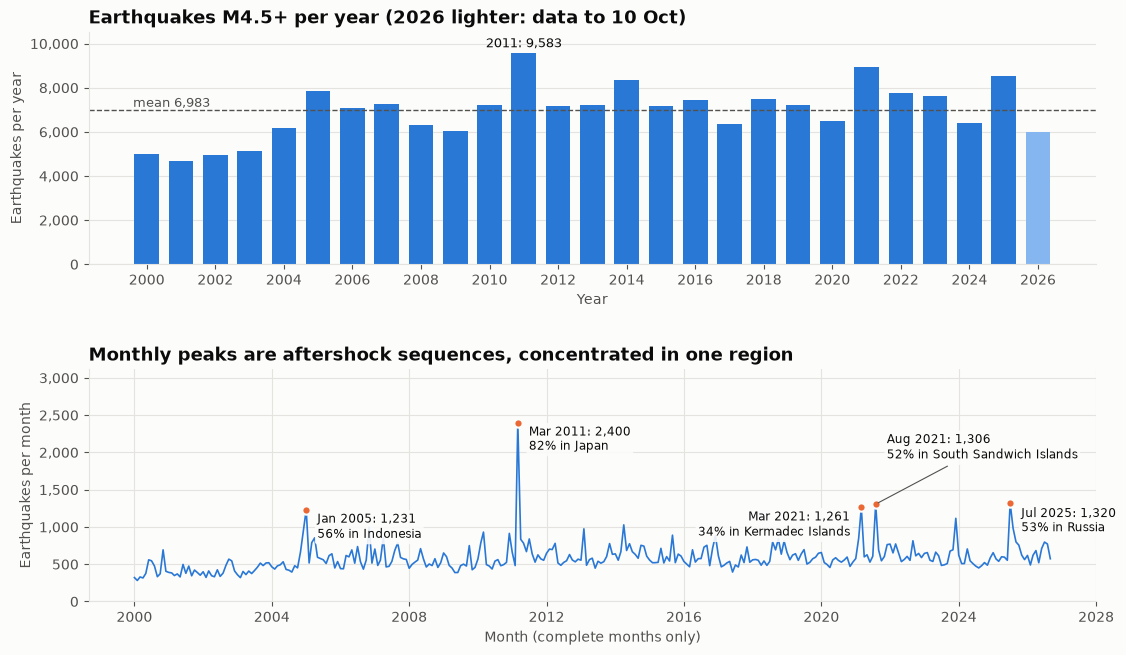

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7.4), gridspec_kw={"hspace": 0.45})

colors = [BLUE if c else "#86b6ef" for c in per_year["complete_year"]]
ax1.bar(per_year.index, per_year["n"], color=colors, width=0.72)
ax1.axhline(full.mean(), color=MUTED, lw=1, ls="--")
ax1.text(per_year.index.min() - 0.4, full.mean() + 150, f"mean {full.mean():,.0f}", color=MUTED, fontsize=9)
top = full.idxmax()
ax1.annotate(f"{top}: {full.max():,}", (top, full.max()), xytext=(0, 4), textcoords="offset points",
             ha="center", fontsize=9, color=INK)
partial_note = f" ({partial_year} lighter: data to {last:%d %b})" if partial_year else ""
ax1.set_ylim(0, per_year["n"].max() * 1.1)
ax1.yaxis.set_major_formatter(thousands)
ax1.set_xticks(per_year.index[::2])
ax1.set_xlabel("Year"); ax1.set_ylabel("Earthquakes per year")
ax1.set_title(f"Earthquakes M4.5+ per year{partial_note}")
ax1.grid(axis="x", visible=False)

ax2.plot(months.index, months["n"], color=BLUE, lw=1.2)
prev = None
nxt = list(peaks.index[1:]) + [None]
for (m, r), after in zip(peaks.iterrows(), nxt):
    left = after is not None and (after - m).days < 400
    ax2.plot(m, r["n"], "o", ms=6, color=ORANGE, mec=SURFACE, mew=1.5)
    close = prev is not None and (m - prev).days < 400      # stack labels of peaks close in time
    ax2.annotate(f"{m:%b %Y}: {r['n']:,}\n{r['top_region_pct']:.0f}% in {r['top_region']}", (m, r["n"]),
                 xytext=(8, 30) if close else (-8, -2) if left else (8, -2), textcoords="offset points",
                 fontsize=8.5, va="bottom" if close else "top", ha="right" if left and not close else "left",
                 color=INK,
                 bbox={"boxstyle": "round,pad=0.2", "fc": SURFACE, "ec": "none", "alpha": 0.9},
                 arrowprops={"arrowstyle": "-", "color": MUTED, "lw": 0.8} if close else None)
    prev = m
ax2.yaxis.set_major_formatter(thousands)
ax2.set_ylim(0, peaks["n"].max() * 1.3)
ax2.set_xlabel("Month (complete months only)"); ax2.set_ylabel("Earthquakes per month")
ax2.set_title("Monthly peaks are aftershock sequences, concentrated in one region")
save_fig(fig, "step4_events_over_time.png")
plt.show()

## 5. Magnitude: each step up is about ten times rarer

The Gutenberg-Richter law says log10 N(>= M) = a - b * M with b close to 1, so
an earthquake one magnitude larger is about ten times rarer. This is where the
class imbalance of Step 8 comes from. `b` is estimated with the Aki maximum
likelihood formula above the completeness magnitude `Mc` (maximum-curvature
method + 0.2, the usual correction). The catalog mixes magnitude scales
(mostly mb, see Step 3), so treat `b` as approximate; the standard error below
only reflects sample size.

completeness magnitude Mc (max curvature + 0.2): 4.7
Gutenberg-Richter b-value (Aki MLE, M >= Mc): 1.14
b-value standard error: 0.003
largest magnitude: 9.1
major earthquakes (M >= 6.5): 1218
major earthquakes pct: 0.649
saved C:\Users\user\Documents\assignment\earthquake_project\figures\step4_magnitude_hist.png


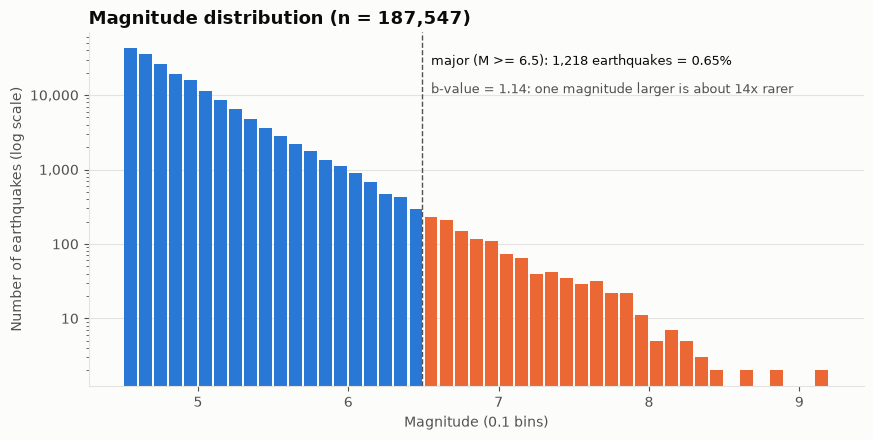

In [7]:
BIN = 0.1
edges = np.round(np.arange(MIN_MAG, df["mag"].max() + BIN * 2, BIN), 1)
h, _ = np.histogram(df["mag"], bins=edges)
Mc = float(edges[np.argmax(h)]) + 0.2
above = df.loc[df["mag"] >= Mc - 1e-9, "mag"]
b = np.log10(np.e) / (above.mean() - (Mc - BIN / 2))
b_se = b / np.sqrt(len(above))

n_major = int(df["is_major"].sum())
fact("completeness magnitude Mc (max curvature + 0.2)", round(Mc, 1))
fact("Gutenberg-Richter b-value (Aki MLE, M >= Mc)", round(b, 2))
fact("b-value standard error", round(b_se, 3))
fact("largest magnitude", df["mag"].max())
fact(f"major earthquakes (M >= {MAJOR_MAG})", n_major)
fact("major earthquakes pct", round(n_major / n * 100, 3))

fig, ax = plt.subplots(figsize=(10, 4.6))
left = edges[:-1]
ax.bar(left + BIN / 2, h, width=BIN * 0.86, color=[ORANGE if e >= MAJOR_MAG - 1e-9 else BLUE for e in left])
ax.set_yscale("log")
ax.axvline(MAJOR_MAG - BIN * 0.07, color=MUTED, lw=1, ls="--")
ax.text(MAJOR_MAG + 0.05, h.max() * 0.6,
        f"major (M >= {MAJOR_MAG}): {n_major:,} earthquakes = {n_major / n * 100:.2f}%",
        color=INK, fontsize=9.5)
ax.text(MAJOR_MAG + 0.05, h.max() * 0.25,
        f"b-value = {b:.2f}: one magnitude larger is about {10 ** b:.0f}x rarer", color=MUTED, fontsize=9.5)
ax.yaxis.set_major_formatter(thousands)
ax.set_xlabel("Magnitude (0.1 bins)")
ax.set_ylabel("Number of earthquakes (log scale)")
ax.set_title(f"Magnitude distribution (n = {n:,})")
ax.grid(axis="x", visible=False)
save_fig(fig, "step4_magnitude_hist.png")
plt.show()

## 6. Depth by depth class

Shallow < 70 km, intermediate 70-300 km, deep > 300 km. The tall 10 km bar is
mostly the default depth flagged in Step 3 (`depth_fixed`).

saved C:\Users\user\Documents\assignment\earthquake_project\figures\step4_depth_hist.png


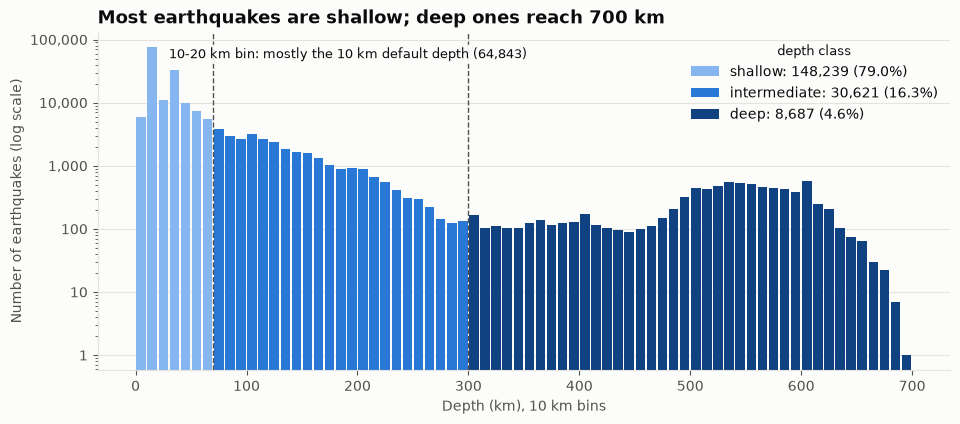

shallow pct: 79.04


intermediate pct: 16.33
deep pct: 4.63
depth_fixed pct: 46.43
max depth (km): 700.9


In [8]:
edges = np.arange(0, 710, 10)
fig, ax = plt.subplots(figsize=(11, 4.4))
for cls in DEPTH_ORDER:
    s = df.loc[df["depth_class"] == cls, "depth"].clip(lower=0)
    ax.hist(s, bins=edges, color=DEPTH_COLORS[cls], rwidth=0.86,
            label=f"{cls}: {len(s):,} ({len(s) / n * 100:.1f}%)")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(thousands)
for x in (DEPTH_BINS["intermediate"][0], DEPTH_BINS["deep"][0]):
    ax.axvline(x, color=MUTED, lw=1, ls="--")
fixed10 = int((df["depth_fixed"] & (df["depth"] < 10.0 + 1e-9) & (df["depth"] >= 10.0 - 1e-9)).sum())
ax.annotate(f"10-20 km bin: mostly the 10 km default depth ({fixed10:,})", (20, fixed10),
            xytext=(8, -2), textcoords="offset points", va="center", fontsize=9, color=INK,
            bbox={"boxstyle": "round,pad=0.2", "fc": SURFACE, "ec": "none", "alpha": 0.9})
ax.legend(frameon=False, title="depth class", title_fontsize=9)
ax.set_xlabel("Depth (km), 10 km bins")
ax.set_ylabel("Number of earthquakes (log scale)")
ax.set_title("Most earthquakes are shallow; deep ones reach 700 km")
ax.grid(axis="x", visible=False)
save_fig(fig, "step4_depth_hist.png")
plt.show()

for cls in DEPTH_ORDER:
    fact(f"{cls} pct", round((df["depth_class"] == cls).mean() * 100, 2))
fact("depth_fixed pct", round(df["depth_fixed"].mean() * 100, 2))
fact("max depth (km)", df["depth"].max())

## 7. Top 10 regions

distinct regions: 439
top 10 regions pct of all earthquakes: 52.3
top region: Indonesia (22,784, 12.2%)
saved C:\Users\user\Documents\assignment\earthquake_project\figures\step4_top_regions.png


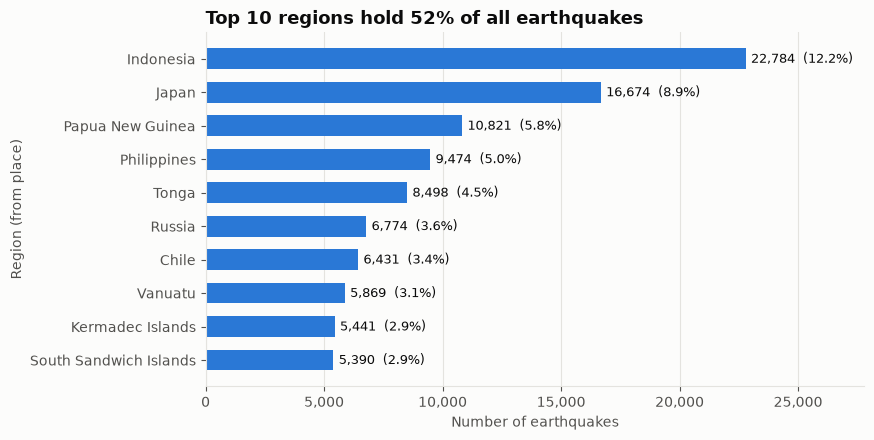

,n,pct
region,,
Indonesia,22784,12.15
Japan,16674,8.89
Papua New Guinea,10821,5.77
Philippines,9474,5.05
Tonga,8498,4.53
Russia,6774,3.61
Chile,6431,3.43
Vanuatu,5869,3.13
Kermadec Islands,5441,2.90


In [9]:
reg = df["region"].value_counts()
top10 = reg.head(10).rename("n").to_frame()
top10["pct"] = (top10["n"] / n * 100).round(2)
top10.index.name = "region"
top10.to_csv(RESULTS_DIR / "step4_top_regions.csv")
fact("distinct regions", reg.size)
fact("top 10 regions pct of all earthquakes", round(top10["pct"].sum(), 1))
fact("top region", f"{top10.index[0]} ({top10['n'].iloc[0]:,}, {top10['pct'].iloc[0]:.1f}%)")

fig, ax = plt.subplots(figsize=(8.5, 4.6))
plot = top10.iloc[::-1]
bars = ax.barh(plot.index, plot["n"], color=BLUE, height=0.62)
for bar, (v, p) in zip(bars, plot[["n", "pct"]].values):
    ax.text(v + top10["n"].max() * 0.01, bar.get_y() + bar.get_height() / 2, f"{v:,.0f}  ({p:.1f}%)",
            va="center", color=INK, fontsize=9)
ax.set_xlim(0, top10["n"].max() * 1.22)
ax.xaxis.set_major_formatter(thousands)
ax.set_xlabel("Number of earthquakes")
ax.set_ylabel("Region (from place)")
ax.set_title(f"Top 10 regions hold {top10['pct'].sum():.0f}% of all earthquakes")
ax.grid(axis="y", visible=False)
save_fig(fig, "step4_top_regions.png")
plt.show()
top10

## 8. Class imbalance: how rare are major earthquakes?

A classifier that always answers "not major" is already this accurate, which
is why Step 8 does not use accuracy.

accuracy of always predicting 'not major' (%): 99.35
non-major to major ratio: 153 : 1
major earthquakes per complete year (mean): 45.6


saved C:\Users\user\Documents\assignment\earthquake_project\figures\step4_major_share.png


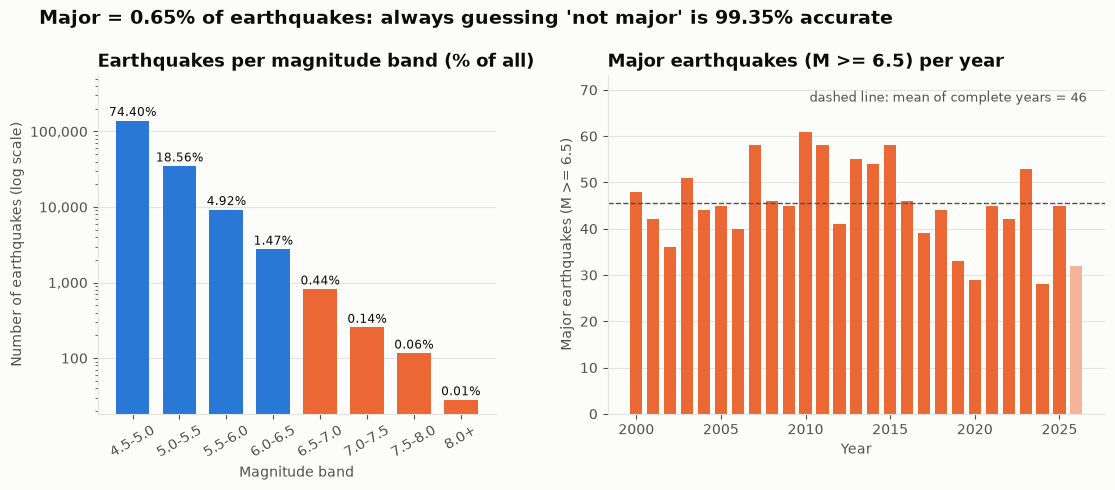

,n,pct,is_major
magnitude band,,,
4.5-5.0,139534,74.399,False
5.0-5.5,34807,18.559,False
5.5-6.0,9229,4.921,False
6.0-6.5,2759,1.471,False
6.5-7.0,819,0.437,True
7.0-7.5,255,0.136,True
7.5-8.0,116,0.062,True
8.0+,28,0.015,True


In [10]:
bands = [4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 10.0]
labels = [f"{a:.1f}-{b:.1f}" for a, b in zip(bands[:-2], bands[1:-1])] + [f"{bands[-2]:.1f}+"]
band = pd.cut(df["mag"], bands, right=False, labels=labels)
band_n = band.value_counts().reindex(labels).rename("n").to_frame()
band_n["pct"] = (band_n["n"] / n * 100).round(3)
band_n["is_major"] = [float(l[:3]) >= MAJOR_MAG for l in labels]
band_n.index.name = "magnitude band"
band_n.to_csv(RESULTS_DIR / "step4_mag_bands.csv")
fact("accuracy of always predicting 'not major' (%)", round((1 - n_major / n) * 100, 2))
fact("non-major to major ratio", f"{(n - n_major) / n_major:.0f} : 1")

major_year = df[df["is_major"] == 1].groupby(df["time"].dt.year).size().reindex(per_year.index, fill_value=0)
fact("major earthquakes per complete year (mean)", round(major_year[per_year["complete_year"]].mean(), 1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={"width_ratios": [1, 1.25], "wspace": 0.25})
bars = ax1.bar(band_n.index.astype(str), band_n["n"], width=0.72,
               color=[ORANGE if m else BLUE for m in band_n["is_major"]])
for bar, (v, p) in zip(bars, band_n[["n", "pct"]].values):
    ax1.text(bar.get_x() + bar.get_width() / 2, v * 1.15, f"{p:.2f}%" if p >= 0.01 else f"{p:.3f}%",
             ha="center", fontsize=8.5, color=INK)
ax1.set_yscale("log")
ax1.set_ylim(top=band_n["n"].max() * 4)
ax1.yaxis.set_major_formatter(thousands)
ax1.set_xlabel("Magnitude band")
ax1.set_ylabel("Number of earthquakes (log scale)")
ax1.set_title("Earthquakes per magnitude band (% of all)")
ax1.tick_params(axis="x", rotation=30)
ax1.grid(axis="x", visible=False)

ax2.bar(major_year.index, major_year.values, width=0.72,
        color=[ORANGE if c else "#f5b397" for c in per_year["complete_year"]])
ax2.axhline(major_year[per_year["complete_year"]].mean(), color=MUTED, lw=1, ls="--")
ax2.set_ylim(0, major_year.max() * 1.2)
ax2.text(major_year.index.max() + 0.6, major_year.max() * 1.12,
         f"dashed line: mean of complete years = {major_year[per_year['complete_year']].mean():.0f}",
         color=MUTED, fontsize=9, ha="right", va="center")
ax2.set_xlabel("Year"); ax2.set_ylabel(f"Major earthquakes (M >= {MAJOR_MAG})")
ax2.set_title(f"Major earthquakes (M >= {MAJOR_MAG}) per year")
fig.suptitle(f"Major = {n_major / n * 100:.2f}% of earthquakes: always guessing 'not major' is "
             f"{(1 - n_major / n) * 100:.2f}% accurate", x=0.08, ha="left", y=1.03,
             fontsize=14, fontweight="bold")
ax2.grid(axis="x", visible=False)
save_fig(fig, "step4_major_share.png")
plt.show()
band_n

## 9. Save the summary

In [11]:
pd.DataFrame(summary).to_csv(RESULTS_DIR / "eda_summary.csv", index=False)
print(f"saved {RESULTS_DIR / 'eda_summary.csv'} ({len(summary)} items)")

saved C:\Users\user\Documents\assignment\earthquake_project\results\eda_summary.csv (31 items)


## 10. Observations (for the slides and the video)

1. **Earthquakes sit on plate boundaries, not spread over the globe.** The top 10
   regions hold 52.3% of all 187,547 earthquakes (Indonesia alone 12.2%), and only
   1,206 grid cells ever had one. Distances must be measured on the Earth's surface
   (haversine), which is why Step 5 does not use plain degrees.
2. **Earthquakes come in bursts.** The five busiest months are each one aftershock
   sequence: March 2011 had 2,400 earthquakes (82% in Japan) against a mean of 584
   per month, and January 2005 is the Sumatra aftershocks (56% in Indonesia). The
   Tohoku M9.1 was followed by 1,910 M4.5+ earthquakes within 300 km in 30 days.
   Events are not independent, which is what ST-DBSCAN (Step 5) is for.
3. **Big earthquakes are rare by nature.** Each magnitude step up is about 14 times
   rarer (b-value about 1.14, approximate because magnitude scales are mixed).
   Major earthquakes (M >= 6.5) are 1,218 rows = 0.65%, a 153 : 1 imbalance:
   always answering "not major" is 99.35% accurate, so Step 8 uses precision,
   recall, F1 and PR-AUC instead of accuracy.
4. **Most earthquakes are shallow, but depth is not trustworthy near the surface.**
   79.0% are shallow, 4.6% deep (down to 701 km, with a second peak at 500-600 km),
   yet 46.4% of all depths are default values (Step 3). Depth features should be
   used with `depth_fixed` in mind.
5. **The catalog itself changes over time.** 2000-2003 have about 4,700-5,100
   earthquakes per year against a mean of 6,983 for all complete years. This is
   most likely better detection, not more earthquakes; it is one more reason to
   split train and test by time (Step 8).